# Model Evaluation — REPSOL Industrial Sound Classification

Evaluate and compare all trained models on the REPSOL test set (297 samples, 8 classes).

**Models compared:**
- `EfficientNet_02` — the current baseline (70% test accuracy)
- `ResNet50_01` — deeper backbone, overfit-prone on this dataset
- `EfficientNet_03` — OneCycleLR + label smoothing + boosted class weights
- `MobileNetV3_01` — lightweight CPU-optimised backbone (skipped until trained)

**Metrics:**
- Accuracy, balanced accuracy, MCC (Matthews correlation — robust single score under imbalance)
- Precision / Recall / F1 (weighted & macro), Top-2 accuracy
- Per-class Precision / Recall / F1 / one-vs-rest AUC
- Confusion matrices (counts + normalised), ROC curves per class
- Per-class F1 heatmap + delta vs best model
- Confidence distributions, learning curves, misclassification analysis
- Model agreement: universally-hard samples + oracle ensemble ceiling

**Caching:** inference results are stored in `outputs/evaluation/cache/{ModelName}.npz`.
Re-running the notebook loads the cache instantly. Set `FORCE_RERUN = True` after retraining a model
(or delete its `.npz` file) to refresh its results.

## 0. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path(r"D:\Work\Internships\INMAR\REPSOL")
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

# ── Set to True to re-run inference even if cache exists ──
FORCE_RERUN = False

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Repo root: {REPO_ROOT}")

Device: cpu
Repo root: D:\Work\Internships\INMAR\REPSOL


## 1. Paths

In [ ]:
SPECT_DIR     = REPO_ROOT / "Data" / "Spectrograms"
MODELS_OUTPUT = REPO_ROOT / "Models_output"
EVAL_OUT      = REPO_ROOT / "outputs" / "evaluation"
CACHE_DIR     = EVAL_OUT / "cache"
EVAL_OUT.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Add/remove checkpoints here ──
# Missing checkpoints are skipped automatically (e.g. MobileNetV3 before its first training run).
CHECKPOINTS = {
    "EfficientNet_02": MODELS_OUTPUT / "efficientnet_best_02.pth",
    "ResNet50_01":     MODELS_OUTPUT / "resnet50_best_01.pth",
    "EfficientNet_03": MODELS_OUTPUT / "efficientnet_best_03_01.pth",
    "MobileNetV3_01":  MODELS_OUTPUT / "mobilenetv3_best_01.pth",
}

# model_name passed to the model factory for each checkpoint
MODEL_TYPES = {
    "EfficientNet_02": "efficientnet",
    "ResNet50_01":     "resnet50",
    "EfficientNet_03": "efficientnet",
    "MobileNetV3_01":  "mobilenetv3",
}

HISTORIES = {
    "EfficientNet_02": MODELS_OUTPUT / "efficientnet_best_02_training_history.csv",
    "ResNet50_01":     MODELS_OUTPUT / "resnet50_best_01_training_history.csv",
    "EfficientNet_03": MODELS_OUTPUT / "efficientnet_best_03_01_training_history.csv",
    "MobileNetV3_01":  MODELS_OUTPUT / "mobilenetv3_best_01_training_history.csv",
}

print("Checkpoints:")
for name, path in CHECKPOINTS.items():
    status = "✓" if path.exists() else "✗ MISSING (will skip)"
    print(f"  {status}  {name}: {path.name}")

print("\nCache files:")
for name in CHECKPOINTS:
    cache = CACHE_DIR / f"{name}.npz"
    status = "cached" if cache.exists() else "not cached"
    print(f"  {name}: {status}")

## 2. Load Test DataLoader

In [3]:
from src.dataloaders import get_dataloaders

_, _, test_loader = get_dataloaders(
    SPECT_DIR, batch_size=32, num_workers=0, pin_memory=False, persistent_workers=False,
)

CLASS_NAMES = test_loader.dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Test samples : {len(test_loader.dataset)}")
print(f"Classes ({NUM_CLASSES}):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {i}: {c}")

Test samples : 297
Classes (8):
  0: 0 ActividadBASE_NO pattern activity
  1: 1 Pulses HAMMERING
  2: 2 Marked cycles 3 segundos
  3: 3 Continuous activity & tone 3.15kHz_SPL ALTO
  4: 4 Continuous activity & tone 3.15kHz_ SPL BAJO
  5: 5 Blasts
  6: 6 Machinery continuous activity
  7: 7 Works_ sirens and knocks en altas frecuencias RAFAGAS a 3.15


## 3. Inference + Caching

In [ ]:
from src.PreTrained_model.load_pretrained import load_model as load_efficientnet


def _load_model_for_eval(name, ckpt_path, model_type, num_classes, device):
    """Load the right model class depending on model_type."""
    if model_type in ("efficientnet", "efficientnet_b0", "b0"):
        model, _ = load_efficientnet(
            checkpoint_path=str(ckpt_path),
            model_name="efficientnet",
            num_classes=num_classes,
            device=device,
        )
        return model
    elif model_type in ("resnet50", "resnet", "r50"):
        from src.ResNet.model import get_model as get_resnet
        model = get_resnet(model_name="resnet50", num_classes=num_classes).to(device)
        state = torch.load(str(ckpt_path), map_location=device)
        model.load_state_dict(state)
        model.eval()
        return model
    elif model_type in ("mobilenet", "mobilenetv3", "mobilenet_v3", "v3"):
        from src.MobileNet.model import get_model as get_mobilenet
        model = get_mobilenet(model_name="mobilenetv3", num_classes=num_classes).to(device)
        state = torch.load(str(ckpt_path), map_location=device)
        model.load_state_dict(state)
        model.eval()
        return model
    else:
        raise ValueError(f"Unknown model_type: {model_type!r}")


def run_inference(model, loader, device):
    model.eval()
    all_true, all_pred, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            probs = torch.softmax(model(x), dim=1).cpu().numpy()
            all_true.extend(y.numpy())
            all_pred.extend(probs.argmax(1))
            all_probs.append(probs)
    return np.array(all_true), np.array(all_pred), np.vstack(all_probs)


def load_or_run(name, ckpt_path, model_type, loader, num_classes, device, force=False):
    cache_path = CACHE_DIR / f"{name}.npz"

    if not force and cache_path.exists():
        print(f"  [{name}] Loading from cache: {cache_path.name}")
        data = np.load(cache_path)
        return data["y_true"], data["y_pred"], data["y_probs"]

    print(f"  [{name}] Running inference ...")
    model = _load_model_for_eval(name, ckpt_path, model_type, num_classes, device)
    y_true, y_pred, y_probs = run_inference(model, loader, device)
    del model  # free memory
    np.savez_compressed(cache_path, y_true=y_true, y_pred=y_pred, y_probs=y_probs)
    print(f"  [{name}] Saved to cache: {cache_path.name}")
    return y_true, y_pred, y_probs


# ── Run / load all models ──
raw_results = {}
for model_name, ckpt_path in CHECKPOINTS.items():
    if not ckpt_path.exists():
        print(f"  [{model_name}] Skipping — checkpoint not found")
        continue
    y_true, y_pred, y_probs = load_or_run(
        model_name, ckpt_path, MODEL_TYPES[model_name],
        test_loader, NUM_CLASSES, DEVICE, force=FORCE_RERUN,
    )
    raw_results[model_name] = (y_true, y_pred, y_probs)

print("\nReady:", list(raw_results.keys()))

## 4. Compute Metrics

In [ ]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score


def compute_metrics(y_true, y_pred, y_probs, class_names):
    n = len(class_names)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)  # mean per-class recall — robust to imbalance
    mcc = matthews_corrcoef(y_true, y_pred)            # -1..1, robust single-number quality score
    pw, rw, f1w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    pm, rm, f1m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
    top2 = sum(y_true[i] in np.argsort(y_probs[i])[-2:] for i in range(len(y_true))) / len(y_true)

    y_bin = label_binarize(y_true, classes=range(n))
    try:
        auc_macro = roc_auc_score(y_bin, y_probs, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = float("nan")

    # per-class one-vs-rest AUC
    auc_per_class = []
    for i in range(n):
        try:
            auc_per_class.append(roc_auc_score(y_bin[:, i], y_probs[:, i]))
        except Exception:
            auc_per_class.append(float("nan"))

    max_conf     = y_probs.max(axis=1)
    correct_mask = y_true == y_pred
    prec_pc, rec_pc, f1_pc, sup_pc = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0, labels=range(n)
    )
    per_class_df = pd.DataFrame({
        "class":     class_names,
        "precision": prec_pc, "recall": rec_pc, "f1": f1_pc,
        "auc":       auc_per_class,
        "support":   sup_pc.astype(int),
    })
    return {
        "accuracy": acc, "balanced_accuracy": bal_acc, "mcc": mcc,
        "precision_weighted": pw, "recall_weighted": rw, "f1_weighted": f1w,
        "precision_macro": pm, "recall_macro": rm, "f1_macro": f1m,
        "top2_accuracy": top2, "roc_auc_macro": auc_macro,
        "mean_conf_correct": max_conf[correct_mask].mean() if correct_mask.any() else float("nan"),
        "mean_conf_wrong":   max_conf[~correct_mask].mean() if (~correct_mask).any() else float("nan"),
        "per_class": per_class_df,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=range(n)),
        "y_true": y_true, "y_pred": y_pred, "y_probs": y_probs,
    }


results = {
    name: compute_metrics(yt, yp, ypr, CLASS_NAMES)
    for name, (yt, yp, ypr) in raw_results.items()
}
print("Metrics computed for:", list(results.keys()))

## 5. Summary Table

In [ ]:
SCALAR_KEYS = [
    "accuracy", "balanced_accuracy", "mcc",
    "precision_weighted", "recall_weighted", "f1_weighted",
    "precision_macro", "recall_macro", "f1_macro",
    "top2_accuracy", "roc_auc_macro", "mean_conf_correct", "mean_conf_wrong",
]

summary = pd.DataFrame(
    {name: {k: m[k] for k in SCALAR_KEYS} for name, m in results.items()}
).T.round(4)

# Rank models by macro F1 (fairest single number under class imbalance)
summary = summary.sort_values("f1_macro", ascending=False)
print(f"Best model by macro F1: {summary.index[0]}\n")

# Highlight the best value in each column
display(summary.style.highlight_max(axis=0, color="#c6efce"))

## 6. Confusion Matrices

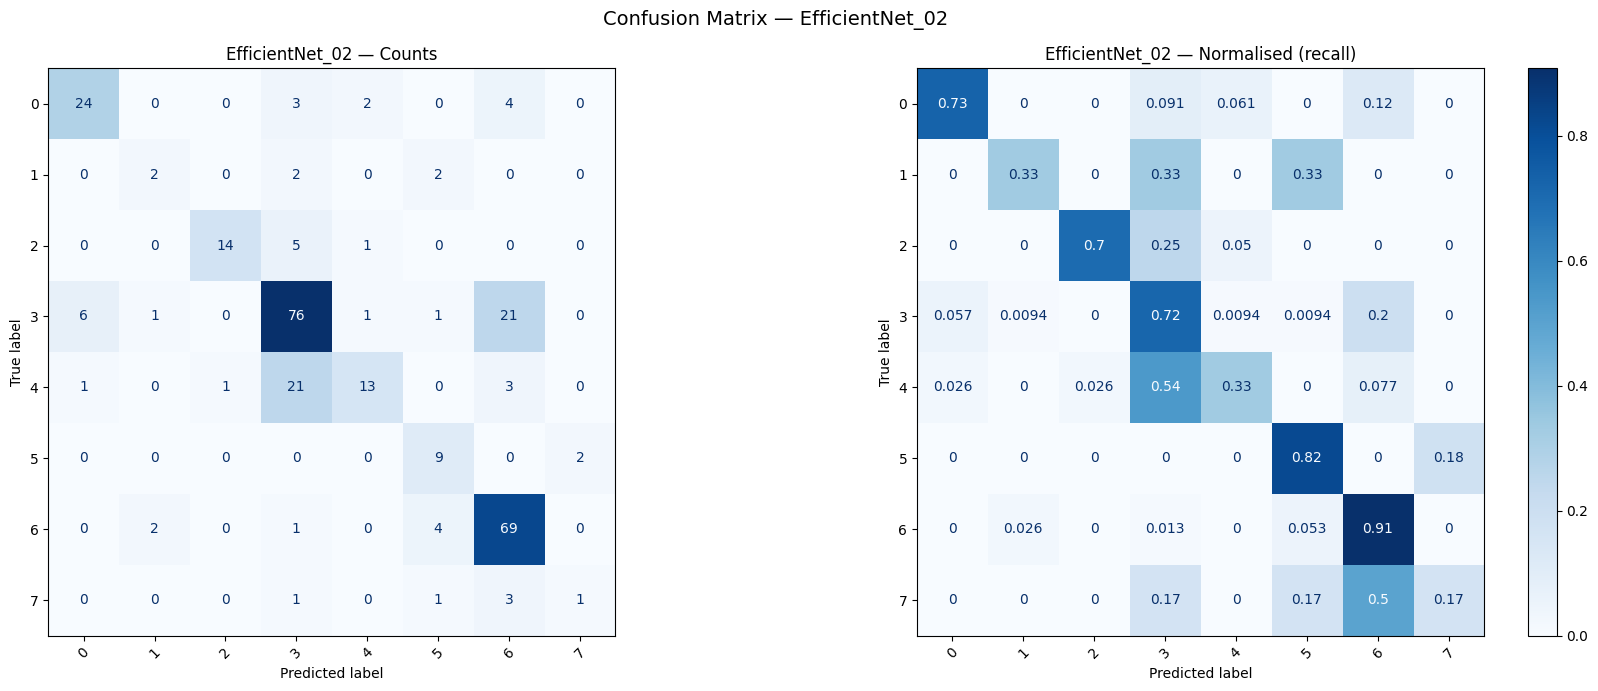

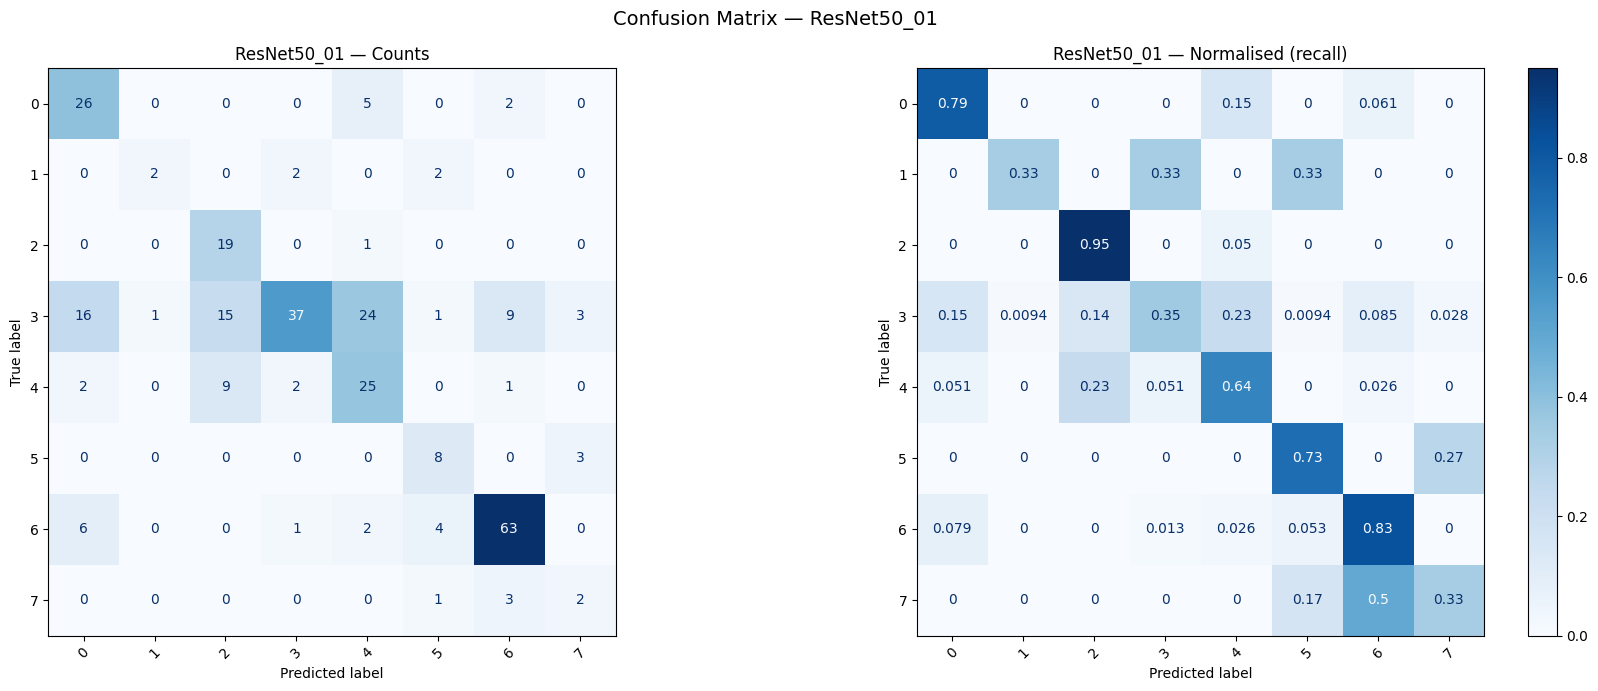

In [7]:
SHORT = [c.split()[0] for c in CLASS_NAMES]

for model_name, m in results.items():
    cm = m["confusion_matrix"]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    ConfusionMatrixDisplay(cm, display_labels=SHORT).plot(
        ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45)
    axes[0].set_title(f"{model_name} — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    ConfusionMatrixDisplay(cm_norm, display_labels=SHORT).plot(
        ax=axes[1], cmap="Blues", colorbar=True, xticks_rotation=45)
    axes[1].set_title(f"{model_name} — Normalised (recall)")

    fig.suptitle(f"Confusion Matrix — {model_name}", fontsize=14)
    fig.tight_layout()
    fig.savefig(EVAL_OUT / f"confusion_matrix_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Per-Class Metrics

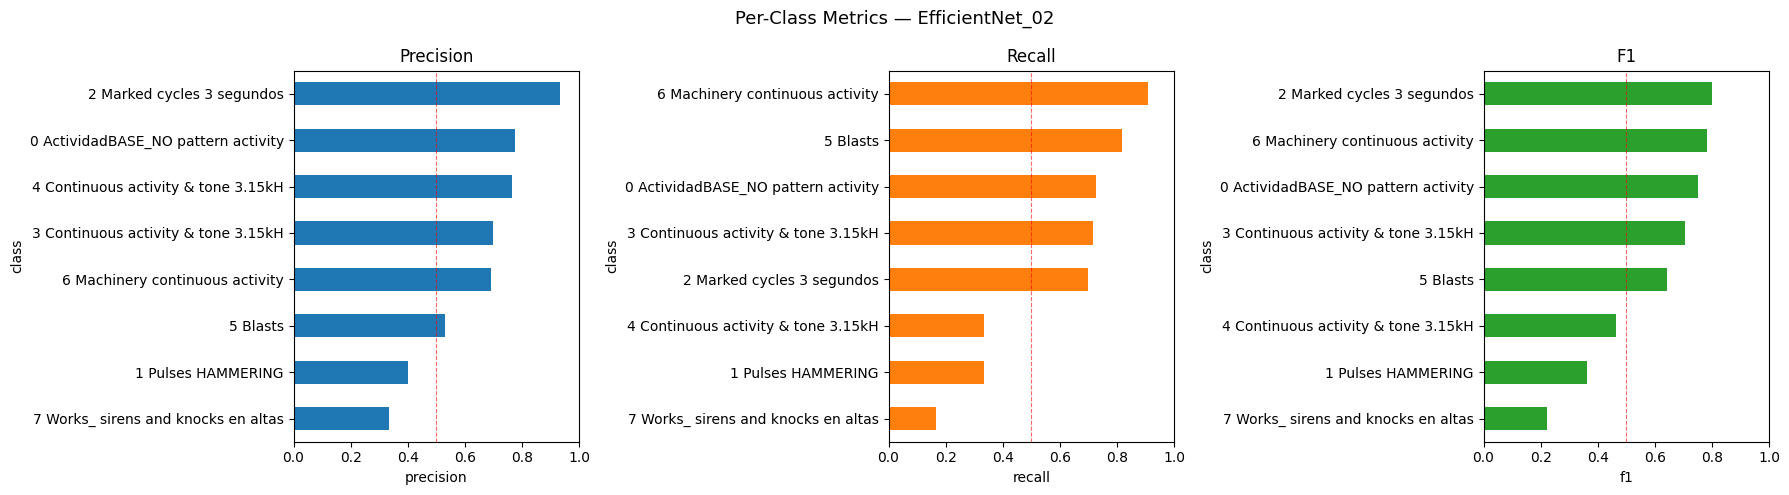

,precision,recall,f1,support
class,,,,
0 ActividadBASE_NO pattern activity,0.774,0.727,0.750,33
1 Pulses HAMMERING,0.400,0.333,0.364,6
2 Marked cycles 3 segundos,0.933,0.700,0.800,20
3 Continuous activity & tone 3.15kH,0.697,0.717,0.707,106
4 Continuous activity & tone 3.15kH,0.765,0.333,0.464,39
5 Blasts,0.529,0.818,0.643,11
6 Machinery continuous activity,0.690,0.908,0.784,76
7 Works_ sirens and knocks en altas,0.333,0.167,0.222,6


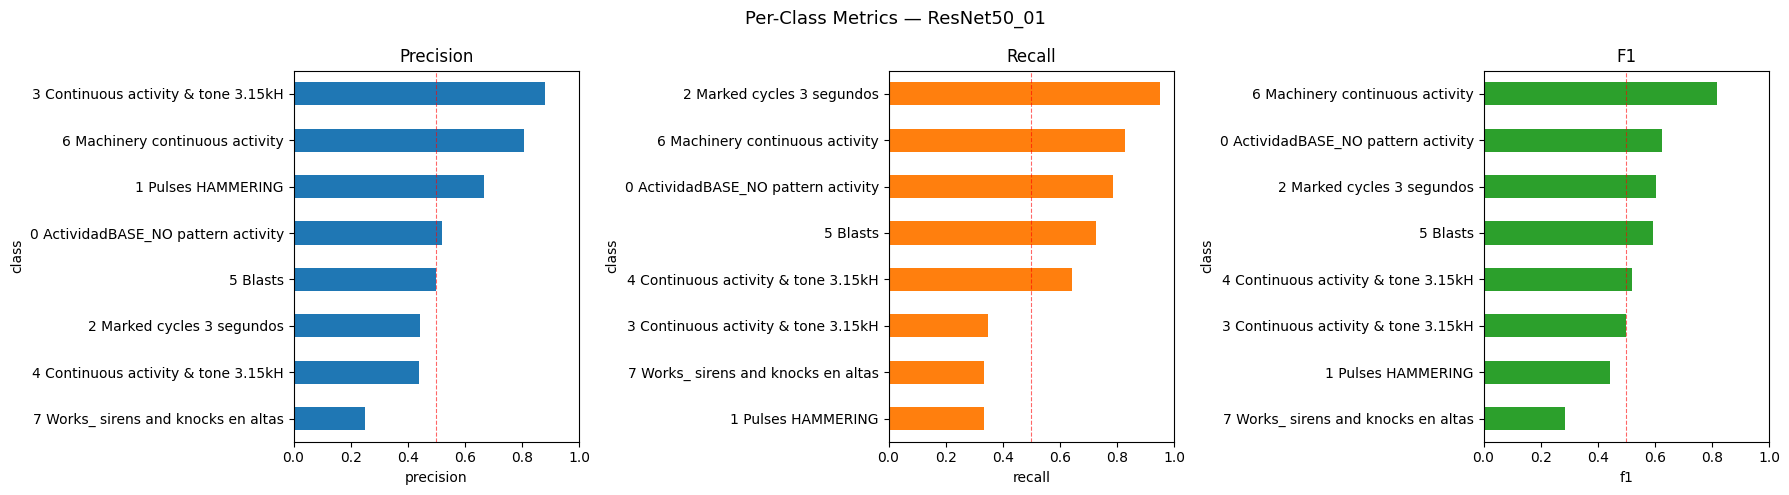

,precision,recall,f1,support
class,,,,
0 ActividadBASE_NO pattern activity,0.520,0.788,0.627,33
1 Pulses HAMMERING,0.667,0.333,0.444,6
2 Marked cycles 3 segundos,0.442,0.950,0.603,20
3 Continuous activity & tone 3.15kH,0.881,0.349,0.500,106
4 Continuous activity & tone 3.15kH,0.439,0.641,0.521,39
5 Blasts,0.500,0.727,0.593,11
6 Machinery continuous activity,0.808,0.829,0.818,76
7 Works_ sirens and knocks en altas,0.250,0.333,0.286,6


In [8]:
for model_name, m in results.items():
    df = m["per_class"].copy()
    df["class"] = df["class"].str[:35]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, col, color in zip(axes, ["precision", "recall", "f1"], ["C0", "C1", "C2"]):
        df.sort_values(col).plot.barh(x="class", y=col, ax=ax, color=color, legend=False)
        ax.set_xlim(0, 1); ax.set_xlabel(col); ax.set_title(col.capitalize())
        ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.6)

    fig.suptitle(f"Per-Class Metrics — {model_name}", fontsize=13)
    fig.tight_layout()
    fig.savefig(EVAL_OUT / f"per_class_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    display(df.set_index("class").round(3))

## 8. Model Comparison — F1 per Class

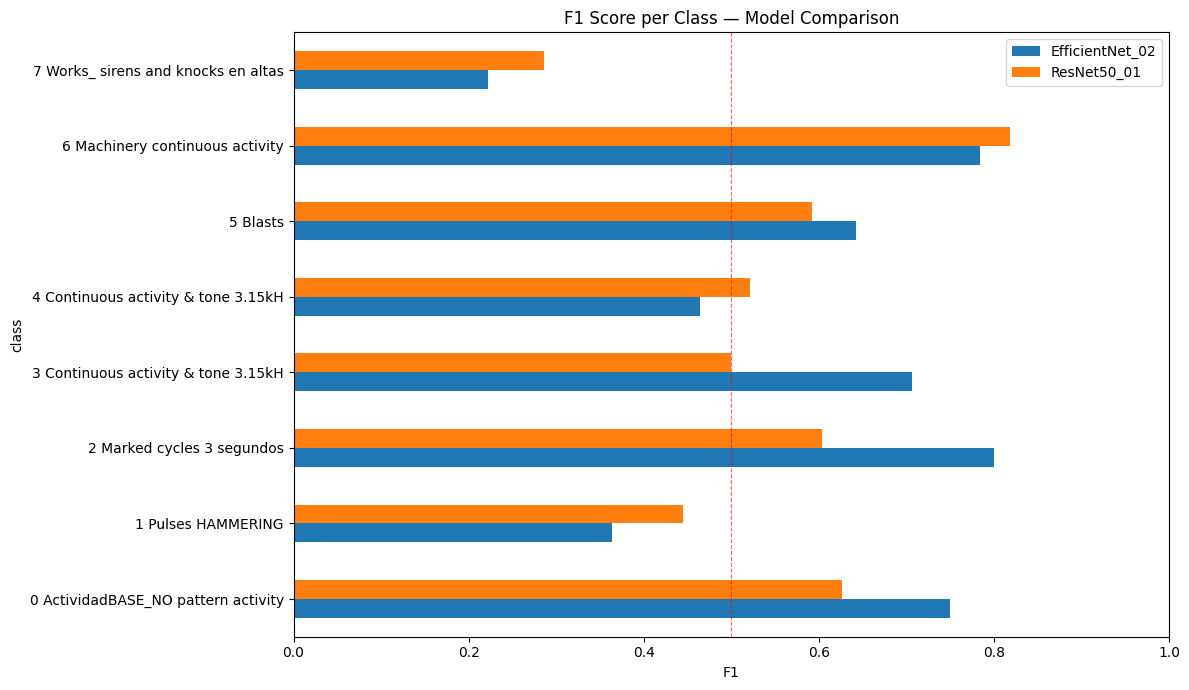

In [9]:
f1_compare = pd.DataFrame(
    {name: m["per_class"].set_index("class")["f1"] for name, m in results.items()}
)
f1_compare.index = f1_compare.index.str[:35]

ax = f1_compare.plot.barh(figsize=(12, 7))
ax.set_xlim(0, 1)
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("F1 Score per Class — Model Comparison")
ax.set_xlabel("F1")
plt.tight_layout()
plt.savefig(EVAL_OUT / "f1_comparison_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 8b. Per-Class F1 Heatmap — all models at a glance

In [ ]:
# Rows = classes, columns = models. Green = good, red = bad.
# The fastest way to spot which classes are universally hard vs model-specific failures.
heat = pd.DataFrame(
    {name: m["per_class"].set_index("class")["f1"] for name, m in results.items()}
)
heat.index = [c[:38] for c in heat.index]

fig, ax = plt.subplots(figsize=(2 + 2.2 * len(results), 6))
sns.heatmap(
    heat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, cbar_kws={"label": "F1"}, ax=ax,
)
ax.set_title("Per-Class F1 — Model Comparison Heatmap")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(EVAL_OUT / "f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Delta vs the best model — where does each model lose ground?
best_name = summary.index[0]
print(f"F1 delta vs best model ({best_name}):")
display((heat.sub(heat[best_name], axis=0)).drop(columns=[best_name]).round(3))

## 8c. ROC Curves (one-vs-rest)

One subplot per model, one curve per class. A curve hugging the top-left corner = that class is well separated by the model's probability scores, even if the final argmax prediction is wrong. Useful for spotting classes where the model is "almost right" (good AUC, bad F1) — those are fixable with threshold/calibration work, unlike classes with bad AUC which need better features.

In [ ]:
from sklearn.metrics import roc_curve

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6), squeeze=False)

for ax, (model_name, m) in zip(axes[0], results.items()):
    y_bin = label_binarize(m["y_true"], classes=range(NUM_CLASSES))
    for i in range(NUM_CLASSES):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], m["y_probs"][:, i])
        auc_i = m["per_class"]["auc"].iloc[i]
        ax.plot(fpr, tpr, label=f"[{i}] {CLASS_NAMES[i][:22]} (AUC {auc_i:.2f})", linewidth=1.5)
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{model_name} — ROC (macro AUC {m['roc_auc_macro']:.3f})")
    ax.legend(fontsize=7, loc="lower right")

fig.tight_layout()
fig.savefig(EVAL_OUT / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Confidence Distribution

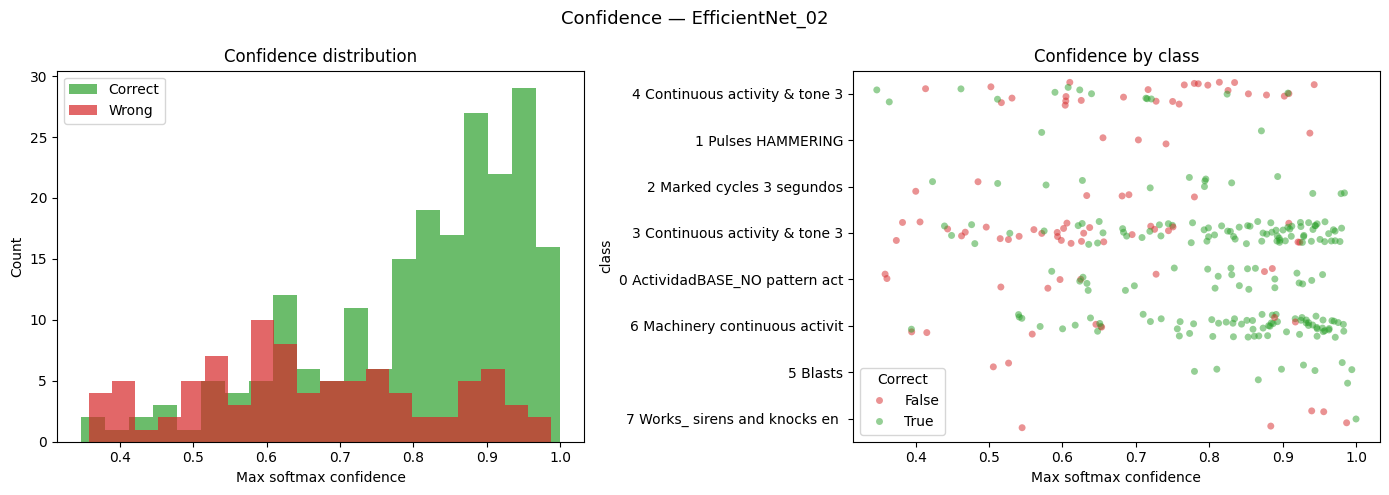

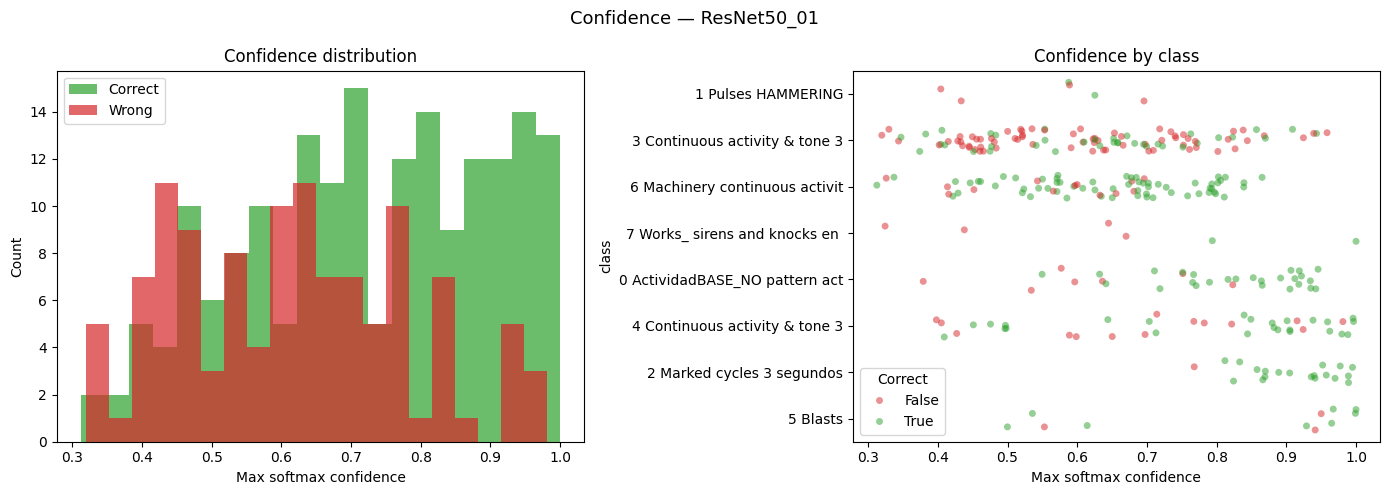

In [10]:
for model_name, m in results.items():
    y_true, y_pred, y_probs = m["y_true"], m["y_pred"], m["y_probs"]
    max_conf = y_probs.max(axis=1)
    correct  = y_true == y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(max_conf[correct],  bins=20, alpha=0.7, label="Correct", color="C2")
    axes[0].hist(max_conf[~correct], bins=20, alpha=0.7, label="Wrong",   color="C3")
    axes[0].set_xlabel("Max softmax confidence"); axes[0].set_ylabel("Count")
    axes[0].set_title("Confidence distribution"); axes[0].legend()

    df_conf = pd.DataFrame({
        "class":      [CLASS_NAMES[i][:30] for i in y_true],
        "confidence": max_conf,
        "correct":    correct,
    })
    class_order = df_conf.groupby("class")["confidence"].median().sort_values().index.tolist()
    sns.stripplot(
        data=df_conf, y="class", x="confidence", hue="correct",
        order=class_order, dodge=False, alpha=0.5, jitter=0.25,
        palette={True: "C2", False: "C3"}, ax=axes[1],
    )
    axes[1].set_title("Confidence by class"); axes[1].set_xlabel("Max softmax confidence")
    axes[1].legend(title="Correct")

    fig.suptitle(f"Confidence — {model_name}", fontsize=13)
    fig.tight_layout()
    fig.savefig(EVAL_OUT / f"confidence_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Learning Curves

  History not found: efficientnet_best_training_history_01.csv


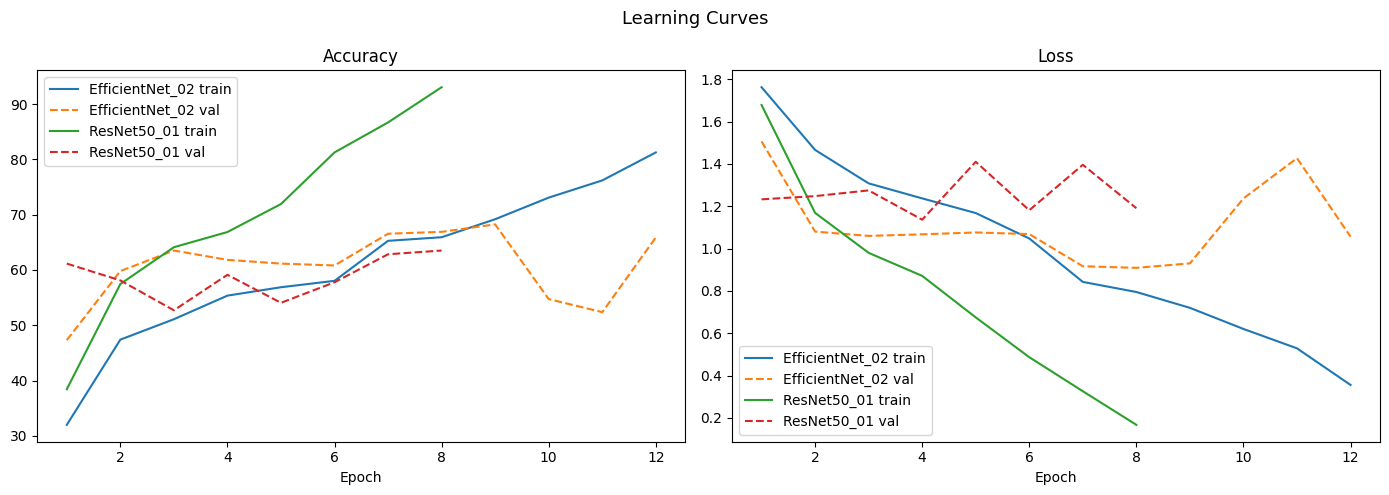

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, hist_path in HISTORIES.items():
    if not hist_path.exists():
        print(f"  History not found: {hist_path.name}")
        continue
    df = pd.read_csv(hist_path)
    acc_col = "train_acc" if "train_acc" in df.columns else "train_accuracy"
    val_col = "val_acc"   if "val_acc"   in df.columns else "val_accuracy"
    axes[0].plot(df["epoch"], df[acc_col],      label=f"{model_name} train")
    axes[0].plot(df["epoch"], df[val_col],      label=f"{model_name} val",   linestyle="--")
    axes[1].plot(df["epoch"], df["train_loss"], label=f"{model_name} train")
    axes[1].plot(df["epoch"], df["val_loss"],   label=f"{model_name} val",   linestyle="--")

axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Loss");     axes[1].set_xlabel("Epoch"); axes[1].legend()
fig.suptitle("Learning Curves", fontsize=13)
fig.tight_layout()
fig.savefig(EVAL_OUT / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Misclassification Analysis

In [12]:
for model_name, m in results.items():
    y_true, y_pred, y_probs = m["y_true"], m["y_pred"], m["y_probs"]
    mask = y_true != y_pred
    df_mis = pd.DataFrame({
        "true":       [CLASS_NAMES[i][:40] for i in y_true[mask]],
        "predicted":  [CLASS_NAMES[i][:40] for i in y_pred[mask]],
        "confidence": y_probs[mask].max(axis=1).round(3),
    })
    top = (
        df_mis.groupby(["true", "predicted"]).size()
        .reset_index(name="count").sort_values("count", ascending=False).head(10)
    )
    print(f"\n{'='*60}")
    print(f"{model_name} — {mask.sum()} misclassified / {len(y_true)}")
    print(f"{'='*60}")
    display(top.reset_index(drop=True))
    df_mis.to_csv(EVAL_OUT / f"misclassified_{model_name}.csv", index=False)


EfficientNet_02 — 89 misclassified / 297


,true,predicted,count
0,4 Continuous activity & tone 3.15kHz_ SP,3 Continuous activity & tone 3.15kHz_SPL,21
1,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous activity,21
2,3 Continuous activity & tone 3.15kHz_SPL,0 ActividadBASE_NO pattern activity,6
3,2 Marked cycles 3 segundos,3 Continuous activity & tone 3.15kHz_SPL,5
4,6 Machinery continuous activity,5 Blasts,4
5,0 ActividadBASE_NO pattern activity,6 Machinery continuous activity,4
6,0 ActividadBASE_NO pattern activity,3 Continuous activity & tone 3.15kHz_SPL,3
7,4 Continuous activity & tone 3.15kHz_ SP,6 Machinery continuous activity,3
8,7 Works_ sirens and knocks en altas frec,6 Machinery continuous activity,3
9,1 Pulses HAMMERING,3 Continuous activity & tone 3.15kHz_SPL,2



ResNet50_01 — 115 misclassified / 297


,true,predicted,count
0,3 Continuous activity & tone 3.15kHz_SPL,4 Continuous activity & tone 3.15kHz_ SP,24
1,3 Continuous activity & tone 3.15kHz_SPL,0 ActividadBASE_NO pattern activity,16
2,3 Continuous activity & tone 3.15kHz_SPL,2 Marked cycles 3 segundos,15
3,4 Continuous activity & tone 3.15kHz_ SP,2 Marked cycles 3 segundos,9
4,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous activity,9
5,6 Machinery continuous activity,0 ActividadBASE_NO pattern activity,6
6,0 ActividadBASE_NO pattern activity,4 Continuous activity & tone 3.15kHz_ SP,5
7,6 Machinery continuous activity,5 Blasts,4
8,5 Blasts,7 Works_ sirens and knocks en altas frec,3
9,3 Continuous activity & tone 3.15kHz_SPL,7 Works_ sirens and knocks en altas frec,3


## 11b. Model Agreement — universally hard samples

Samples that **every** model misclassifies are likely label noise, corrupted spectrograms, or genuinely ambiguous audio — worth listening to manually. Samples where models disagree show where an ensemble could help.

In [ ]:
# Compare only models worth comparing (skip anything below 40% accuracy — collapsed runs distort this)
good_models = {n: m for n, m in results.items() if m["accuracy"] >= 0.40}
print(f"Models included: {list(good_models.keys())}")
print(f"(excluded as collapsed/broken: {[n for n in results if n not in good_models]})\n")

if len(good_models) >= 2:
    names = list(good_models.keys())
    y_true = good_models[names[0]]["y_true"]
    correct_matrix = np.stack(
        [good_models[n]["y_pred"] == y_true for n in names]
    )  # [n_models, n_samples] bool

    n_correct_per_sample = correct_matrix.sum(axis=0)
    all_wrong  = n_correct_per_sample == 0
    all_right  = n_correct_per_sample == len(names)
    disagree   = ~all_wrong & ~all_right

    print(f"Test samples          : {len(y_true)}")
    print(f"All models correct    : {all_right.sum():4d}  ({100*all_right.mean():.1f}%)")
    print(f"Models disagree       : {disagree.sum():4d}  ({100*disagree.mean():.1f}%)  ← ensemble potential")
    print(f"All models wrong      : {all_wrong.sum():4d}  ({100*all_wrong.mean():.1f}%)  ← check these manually")

    # File names of universally-failed samples (from the dataset ordering, shuffle=False for test)
    sample_paths = [Path(p).name for (p, _) in test_loader.dataset.samples]
    df_hard = pd.DataFrame({
        "file":  [sample_paths[i] for i in np.where(all_wrong)[0]],
        "true":  [CLASS_NAMES[y_true[i]][:40] for i in np.where(all_wrong)[0]],
        **{
            n: [CLASS_NAMES[good_models[n]["y_pred"][i]][:25] for i in np.where(all_wrong)[0]]
            for n in names
        },
    })
    print("\nUniversally misclassified samples:")
    display(df_hard)
    df_hard.to_csv(EVAL_OUT / "universally_hard_samples.csv", index=False)

    # Oracle ensemble ceiling: accuracy if we could always pick the right model
    oracle_acc = (n_correct_per_sample > 0).mean()
    best_single = max(m["accuracy"] for m in good_models.values())
    print(f"\nBest single model accuracy : {best_single:.4f}")
    print(f"Oracle ensemble ceiling    : {oracle_acc:.4f}  (+{100*(oracle_acc-best_single):.1f} pts available from ensembling)")
else:
    print("Need at least 2 working models for agreement analysis.")

## 12. Classification Report (Full)

In [13]:
for model_name, m in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report — {model_name}")
    print(f"{'='*60}")
    print(classification_report(m["y_true"], m["y_pred"], target_names=CLASS_NAMES, zero_division=0))


Classification Report — EfficientNet_02
                                                                precision    recall  f1-score   support

                           0 ActividadBASE_NO pattern activity       0.77      0.73      0.75        33
                                            1 Pulses HAMMERING       0.40      0.33      0.36         6
                                    2 Marked cycles 3 segundos       0.93      0.70      0.80        20
                 3 Continuous activity & tone 3.15kHz_SPL ALTO       0.70      0.72      0.71       106
                4 Continuous activity & tone 3.15kHz_ SPL BAJO       0.76      0.33      0.46        39
                                                      5 Blasts       0.53      0.82      0.64        11
                               6 Machinery continuous activity       0.69      0.91      0.78        76
7 Works_ sirens and knocks en altas frecuencias RAFAGAS a 3.15       0.33      0.17      0.22         6

                     

## 13. Save Summary CSV

In [14]:
summary.to_csv(EVAL_OUT / "summary_metrics.csv")
print(f"Saved to {EVAL_OUT}")
for f in sorted(EVAL_OUT.iterdir()):
    if f.is_file():
        print(f"  {f.name}")

Saved to D:\Work\Internships\INMAR\REPSOL\outputs\evaluation
  confidence_EfficientNet_01.png
  confidence_EfficientNet_02.png
  confidence_PreTrained_01.png
  confidence_ResNet50_01.png
  confusion_matrix_EfficientNet_01.png
  confusion_matrix_EfficientNet_02.png
  confusion_matrix_PreTrained_01.png
  confusion_matrix_ResNet50_01.png
  f1_comparison_per_class.png
  learning_curves.png
  misclassified_EfficientNet_01.csv
  misclassified_EfficientNet_02.csv
  misclassified_PreTrained_01.csv
  misclassified_ResNet50_01.csv
  per_class_EfficientNet_01.png
  per_class_EfficientNet_02.png
  per_class_PreTrained_01.png
  per_class_ResNet50_01.png
  summary_metrics.csv
